# Aufgabe 4

## Transferfunktion $U_a/U_e$

Bei der vierten Aufgabe, wurden an einem Hochpassfilter die Eingangs- und Ausgangspannung gemessen für folgende Frequenzen:
| Bereich    | Schrittgröße |
| -------- | ------- |
| 100 - 1000 Hz  | 200 Hz    |
| 1 - 10 kHz | 2 kHz     |
| 10 - 100 kHz    | 5 kHz    |

Und der Hochpassfilter wurde nach dem folgenden Schaltplan aufgebaut, welcher in der Aufgabe gegeben wurde:
![alt text](Bilder/Hochpassfilter.png "Schaltplan Hochpassfilter")

Mit diesen Werten können wir das gemessene Verhältnis $\frac{U_a}{U_e}$ in einem Graphen darstellen. Um die theoretischen Werte für das Verhältnis zu berechnen, nutzen wir wieder die Formel für einen Spannungsteiler. Dabei haben wir für $R$ als den Ohmschen Widerstand und $X_c$ als den Blindwiderstand des Kondensators. Für den Blindwiderstand eines Kondensators gilt: $X_c = \frac{1}{j\omega C}$, wobei die Kreisfrequenz $\omega = 2\pi f$ ist, $C$ die Kapazität des Kondensators und j der Imaginäranteil ist.
$$U_a = U_e \cdot \frac{R}{X_c + R} = U_e \cdot \frac{R}{X_c + R}$$
Diese Formel enthält nicht nur den Betrag der Amplitude sondern auch noch die Phase, weshalb wir um die Amplitude $U_a$ zu bestimmen, den Betrag nutzen:
$$|U_a| = |U_e| \cdot \frac{|R|}{|X_c + R|} \Rightarrow U_a = U_e \cdot \frac{R}{\sqrt{X_c^2 + R^2}} = U_e \cdot \frac{R}{\sqrt{(\frac{1}{2\pi f C})^2 + R^2}} = U_e \cdot \frac{2\pi fCR}{\sqrt{1 + (2\pi fCR)^2}} = U_e \cdot \frac{1}{\sqrt{1 + (\frac{1}{2\pi fCR})^2}}$$


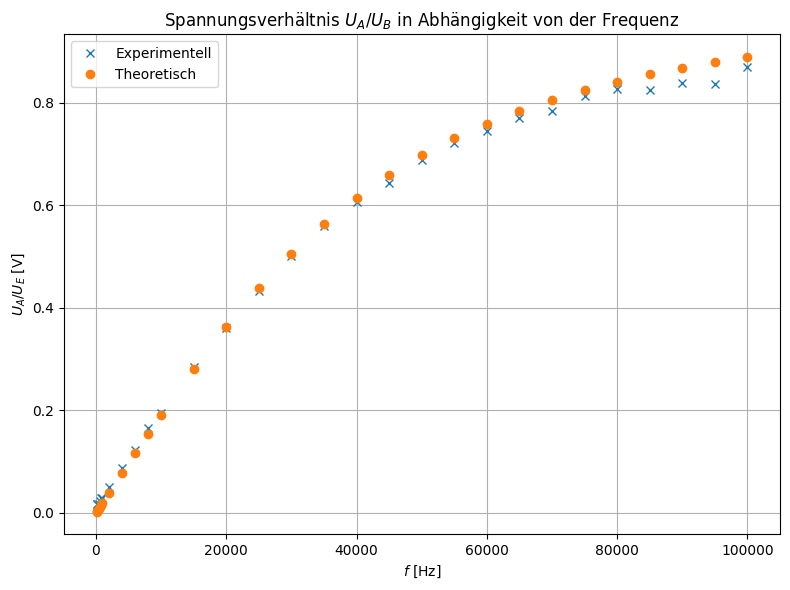

In [43]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_4.csv')
df.columns = ['f [Hz]', 'U_A[V]', 'U_B[V]']

def U_A_E_theor(R, C, f):
    U_A_E_theor = 1/(np.sqrt(1 + (1/(2*np.pi*R*C*f))**2))
    return U_A_E_theor

df['U_A_U_B'] = df['U_A[V]'] / df['U_B[V]']
df['U_A_E_theor'] = U_A_E_theor(200, 1.55e-8, df['f [Hz]'])


# Plot
plt.figure(figsize=(8, 6))
#plt.plot(df['f [Hz]'], df['U_A[V]'], 'o-', label='U_A[V]')
#plt.plot(df['f [Hz]'], df['U_B[V]'], 'x--', label='U_B[V]')
plt.plot(df['f [Hz]'], df['U_A_U_B'], 'x', label='Experimentell')
plt.plot(df['f [Hz]'], df['U_A_E_theor'], 'o', label='Theoretisch')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$U_A/U_E$ [V]')
plt.title(r'Spannungsverhältnis $U_A/U_B$ in Abhängigkeit von der Frequenz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Im zweiten Teil der Aufgabe bestimmen wir die Grenzfrequenz $f_c$. Bei dieser Grenzfrequenz gilt für das Eingangs- und Ausgangssignal: $U_a = U_e/\sqrt{2}$. In der Theorie kann man den Wert mithilfe $R$ und $C$ berechnen, mit der Formel:
$$f_c = \frac{1}{2\pi RC}$$
Bei unserem Versuch hatten wir einen Widerstand mit $R = 200 \Omega$ und einen Kondensator mit $C = 15,5 nF$. Somit ist die berechnete Grenzfrequenz:
$$f_c = \frac{1}{2\pi \cdot 200\Omega \cdot 15,5 \cdot 10^{-9} nF} = 51,340 kHz$$
Der Experimentelle Wert wird bestimmt, indem eine Fit-funktion für die Daten gefunden wird und die Frequenz ausgegeben wird, bei der das Verhältnis $1/\sqrt{2}$ entspricht.

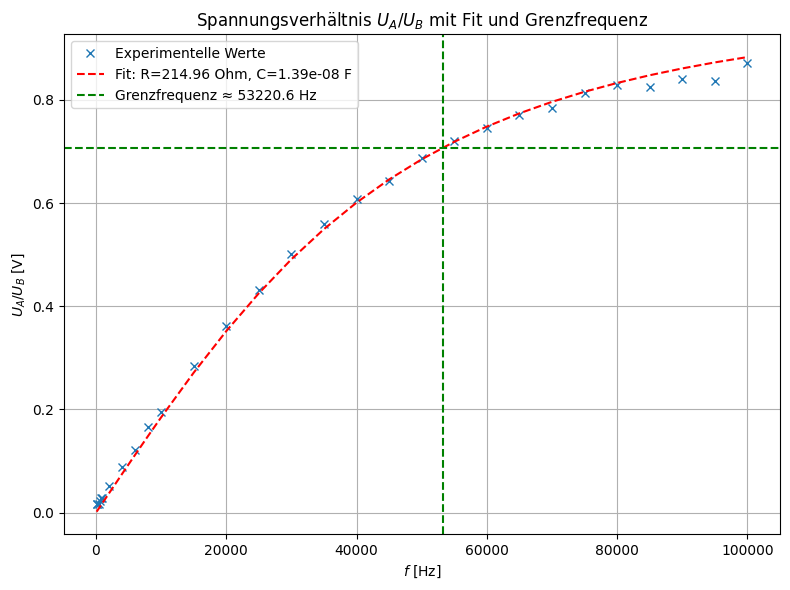

In [45]:
from scipy.optimize import curve_fit, fsolve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_4.csv')
df.columns = ['f [Hz]', 'U_A[V]', 'U_B[V]']

def U_A_E_theor(R, C, f):
    U_A_E_theor = 1/(np.sqrt(1 + (1/(2*np.pi*R*C*f))**2))
    return U_A_E_theor

df['U_A_U_B'] = df['U_A[V]'] / df['U_B[V]']
df['U_A_E_theor'] = U_A_E_theor(200, 1.55e-8, df['f [Hz]'])

popt, pcov = curve_fit(U_A_E_theor, df['f [Hz]'], df['U_A_U_B'], p0=[200, 1.55e-8])
R_fit, C_fit = popt

# Grenzfrequenz berechnen (U_A/U_B = 1/sqrt(2))
def find_cutoff_freq(f):
    return U_A_E_theor(f, R_fit, C_fit) - 1/np.sqrt(2)


f_cutoff = fsolve(find_cutoff_freq, x0=1000)[0]  # Startwert 1000 Hz

# Plot
plt.figure(figsize=(8, 6))
plt.plot(df['f [Hz]'], df['U_A_U_B'], 'x', label='Experimentelle Werte')
plt.plot(df['f [Hz]'], U_A_E_theor(R_fit, C_fit, df['f [Hz]']), 'r--', label='Fit: R=%.2f Ohm, C=%.2e F' % (R_fit, C_fit))
plt.axhline(1/np.sqrt(2), color='green', linestyle='--')
plt.axvline(f_cutoff, color='green', linestyle='--', label=f'Grenzfrequenz ≈ {f_cutoff:.1f} Hz')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$U_A/U_B$ [V]')
plt.title(r'Spannungsverhältnis $U_A/U_B$ mit Fit und Grenzfrequenz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Fehlerbetrachtung

Die Abweichungen bei der Grenzfrequenz betragen 3,66%, welche durch die Fitfunktion entstehen. Der Grenzfrequenz Wert wird bestimmt, indem sich der Wert der Fitfunktion angeschaut wird, bei dem das Verhältnis stimmt. Da die Experimentellen Werte aber nicht komplett mit den theoretischen übereinstimmen, ist auch der Fit nicht genau und der beste der gefunden wurde, stimmt mit den theoretischen Werten für $R=214 \Omega$ und $C= 13,9 nF$ überein. Da dies nicht mit den genutzten Werten übereinstimmt, kann auch die Grenzfrequenz nicht übereinstimmen.

# Fehlertabelle des Digitalmultimeters
[Fehlertabelle des Digitalmultimeters entnommen der Expermentierbeschreibung von Moodel](./Bilder/Fehlermultimeter.png){#fig-fehlertabelle}


# Quellen
Alle Abbildungen der Schaltungen sowie die [Fehlertablle](#fig-fehlertabelle) des Digatalmultimeters wurden der Experiment Beschreibung auf Moodel entnommen